# BEATs Embeddings Experiment

Compare embedding strategies for adaptive tokenization:

1. **Mel-672D** — Assom baseline (LogMelSpec 21×32 flattened)
2. **BEATs-naive** — Microsoft BEATs_iter3+ AS2M, 16 kHz resample (ultrasonic lost above 8 kHz)
3. **BEATs-pitch** — same checkpoint, heterodyne (slow ~16×) so 0–125 kHz maps into BEATs band
4. **NatureBEATs** — encoder from [EarthSpeciesProject/NatureLM-audio](https://huggingface.co/EarthSpeciesProject/NatureLM-audio) (bioacoustics fine-tuned), merged with MS weights for 11 missing `relative_attention_bias` tensors; same **pitch_shift** front-end as BEATs-pitch

For each embedding we report the **Assom baseline** from `adaptive_tokenization.ipynb`: **UMAP → 2D**, **HDBSCAN**, **NCA + KNN** noise reassignment. Plots: context, baseline, adaptive+BPE, silhouette (adaptive).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.pipeline import Pipeline
import umap
import hdbscan

sys.path.insert(0, os.path.abspath('..'))

from src.data import (
    load_annotations, load_segments, dynamic_segmentation, iqr_filter,
    CONTEXT_DICT,
)
from src.features import compute_spectrograms, compute_beats_embeddings
from src.tokenizer import AdaptiveTokenizer
from src.sequence import build_sequences, build_feature_matrix, classify_context
from src import eval as ev

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')
print('Imports OK')

Imports OK


In [2]:
# ── Configuration ──

DATA_DIR = Path('/Volumes/T7/data/raw/fruitbat')
BEATS_CKPT = '/Volumes/T7/models/beats/BEATs_iter3_plus_AS2M.pt'
# NatureLM-audio (HF); first run writes beats_encoder_merged.pt here
NATURELM_DIR = '/Volumes/T7/models/NatureLM-audio'
SR = 250_000
RANDOM_STATE = 42

USE_DYNAMIC_SEG = True
DYN_SEG_PARAMS = dict(
    n_fft=1024, hop_length_ms=0.5, win_length_ms=4, ref_level_db=20,
    pre=0.97, min_level_db=-30, silence_threshold=0.1,
    min_silence_for_spec=0.1, max_vocal_for_spec=1.0,
    min_syllable_length_s=0.01, spectral_range=[5000, 60000],
    min_level_db_floor=20, verbose=False,
)

SPEC_TIME, SPEC_FREQ = 21, 32

# AdaptiveTokenizer config
AT_PCA_DIM = 50
AT_MIN_CLUSTER_SIZE = 50
AT_MIN_SAMPLES = 10
AT_REFINE_MAX_ITER = 10
AT_BPE_MAX_MERGES = 20
AT_BPE_MIN_BIGRAM = 10

# BEATs batch size (smaller than mel since model is heavier)
BEATS_BATCH = 4

# Baseline UMAP + HDBSCAN + NCA (same as notebooks/adaptive_tokenization.ipynb)
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.3
HDBSCAN_MIN_CLUSTER_FRAC = 0.02
HDBSCAN_MIN_SAMPLES = 20
HDBSCAN_EPSILON = 0.1
NCA_KNN_NEIGHBORS = 30

# RQ1 acoustic proxy (DTW+MFCC+Ward per emitter): cap segments for speed; None = all (slow)
PROXY_MAX_SEG_PER_EMITTER = 400

print('Config OK')

Config OK


## 1. Load Data

In [3]:
df = load_annotations(DATA_DIR)
seg_df = load_segments(df, DATA_DIR)
if USE_DYNAMIC_SEG:
    seg_df = dynamic_segmentation(seg_df, DYN_SEG_PARAMS)
seg_df = iqr_filter(seg_df)
print(f'Segments: {len(seg_df)}')
print(seg_df['context_name'].value_counts())

Loading WAVs:   0%|          | 0/6788 [00:00<?, ?it/s]

Segments loaded: 6870 | skipped: 0


Dynamic segmentation:   0%|          | 0/6870 [00:00<?, ?it/s]

After dynamic segmentation: 29890 sub-segments | failures: 591
IQR filter: kept 27083 / 29890 (bounds [0.0010s, 0.1378s])
Segments: 27083
context_name
Mating protest    7877
Isolation         4913
Fighting          4334
Biting            3191
Feeding           2831
Threat-like       2588
Grooming           620
Kissing            400
Separation         320
Landing              9
Name: count, dtype: int64


## 2. Compute Embeddings

In [4]:
%%time
# 2a. Mel-672D (baseline)
tf_specs = compute_spectrograms(seg_df, target_sr=SR, spec_time=SPEC_TIME, spec_freq=SPEC_FREQ)
X_mel = tf_specs.reshape(len(tf_specs), -1)
print(f'Mel embeddings: {X_mel.shape}')

TF preprocess_model:   0%|          | 0/847 [00:00<?, ?it/s]

Mel embeddings: (27083, 672)
CPU times: user 2min 31s, sys: 34.4 s, total: 3min 5s
Wall time: 1min 13s


In [5]:
%%time
# 2b. BEATs-naive (16kHz resample, loses ultrasonic)
X_beats_naive = compute_beats_embeddings(
    seg_df, checkpoint_path=BEATS_CKPT,
    mode='naive', native_sr=SR, batch_size=BEATS_BATCH,
)
print(f'BEATs-naive embeddings: {X_beats_naive.shape}')

INFO src.beats.BEATs: BEATs Config: {'input_patch_size': 16, 'embed_dim': 512, 'conv_bias': False, 'encoder_layers': 12, 'encoder_embed_dim': 768, 'encoder_ffn_embed_dim': 3072, 'encoder_attention_heads': 12, 'activation_fn': 'gelu', 'layer_wise_gradient_decay_ratio': 1.0, 'layer_norm_first': False, 'deep_norm': True, 'dropout': 0.1, 'attention_dropout': 0.1, 'activation_dropout': 0.0, 'encoder_layerdrop': 0.05, 'dropout_input': 0.1, 'conv_pos': 128, 'conv_pos_groups': 16, 'relative_position_embedding': True, 'num_buckets': 320, 'max_distance': 800, 'gru_rel_pos': True, 'finetuned_model': False, 'predictor_dropout': 0.1, 'predictor_class': 527}


BEATs (microsoft/naive):   0%|          | 0/6771 [00:00<?, ?it/s]

BEATs-naive embeddings: (27083, 768)
CPU times: user 5min 38s, sys: 32.2 s, total: 6min 11s
Wall time: 4min 17s


In [6]:
%%time
# 2c. BEATs-pitch (heterodyne: full spectrum mapped to 0-8kHz)
X_beats_pitch = compute_beats_embeddings(
    seg_df, checkpoint_path=BEATS_CKPT,
    mode='pitch_shift', native_sr=SR, batch_size=BEATS_BATCH,
)
print(f'BEATs-pitch embeddings: {X_beats_pitch.shape}')

INFO src.beats.BEATs: BEATs Config: {'input_patch_size': 16, 'embed_dim': 512, 'conv_bias': False, 'encoder_layers': 12, 'encoder_embed_dim': 768, 'encoder_ffn_embed_dim': 3072, 'encoder_attention_heads': 12, 'activation_fn': 'gelu', 'layer_wise_gradient_decay_ratio': 1.0, 'layer_norm_first': False, 'deep_norm': True, 'dropout': 0.1, 'attention_dropout': 0.1, 'activation_dropout': 0.0, 'encoder_layerdrop': 0.05, 'dropout_input': 0.1, 'conv_pos': 128, 'conv_pos_groups': 16, 'relative_position_embedding': True, 'num_buckets': 320, 'max_distance': 800, 'gru_rel_pos': True, 'finetuned_model': False, 'predictor_dropout': 0.1, 'predictor_class': 527}


BEATs (microsoft/pitch_shift):   0%|          | 0/6771 [00:00<?, ?it/s]

BEATs-pitch embeddings: (27083, 768)
CPU times: user 5min 46s, sys: 30.3 s, total: 6min 16s
Wall time: 4min 16s


In [7]:
%%time
# 2d. NatureBEATs — NatureLM-audio encoder (bioacoustics fine-tuned), pitch_shift front-end
X_nature_beats = compute_beats_embeddings(
    seg_df,
    checkpoint_path=BEATS_CKPT,
    mode='pitch_shift',
    native_sr=SR,
    batch_size=BEATS_BATCH,
    encoder='naturelm',
    naturelm_dir=NATURELM_DIR,
)
print(f'NatureBEATs embeddings: {X_nature_beats.shape}')

INFO src.beats.BEATs: BEATs Config: {'input_patch_size': 16, 'embed_dim': 512, 'conv_bias': False, 'encoder_layers': 12, 'encoder_embed_dim': 768, 'encoder_ffn_embed_dim': 3072, 'encoder_attention_heads': 12, 'activation_fn': 'gelu', 'layer_wise_gradient_decay_ratio': 0.6, 'layer_norm_first': False, 'deep_norm': True, 'dropout': 0.0, 'attention_dropout': 0.0, 'activation_dropout': 0.0, 'encoder_layerdrop': 0.05, 'dropout_input': 0.0, 'conv_pos': 128, 'conv_pos_groups': 16, 'relative_position_embedding': True, 'num_buckets': 320, 'max_distance': 800, 'gru_rel_pos': True, 'finetuned_model': False, 'predictor_dropout': 0.0, 'predictor_class': 527}


BEATs (naturelm/pitch_shift):   0%|          | 0/6771 [00:00<?, ?it/s]

NatureBEATs embeddings: (27083, 768)
CPU times: user 6min, sys: 35.2 s, total: 6min 36s
Wall time: 4min 42s


In [8]:
from src.proxy_labels import compute_acoustic_proxy_labels

# Paper RQ1: DTW on MFCC + Ward + cophenetic q=0.05 per emitter (Assom 0.3 notebook)
ACOUSTIC_PROXY_LABELS, ACOUSTIC_PROXY_MASK = compute_acoustic_proxy_labels(
    seg_df,
    max_segments_per_emitter=PROXY_MAX_SEG_PER_EMITTER,
    cophene_quantile=0.05,
)
print(
    f"Acoustic proxy: {ACOUSTIC_PROXY_MASK.sum()} / {len(seg_df)} segment-rows "
    f"(max {PROXY_MAX_SEG_PER_EMITTER} seg/emitter; set PROXY_MAX_SEG_PER_EMITTER=None for full DTW)"
)

# Free audio memory
if 'audio' in seg_df.columns:
    seg_df = seg_df.drop(columns=['audio', 'sr']).reset_index(drop=True)

### Baseline: UMAP + HDBSCAN + NCA (matches `adaptive_tokenization.ipynb`)

Identical to section *Baseline: UMAP + HDBSCAN* there: Euclidean UMAP to 2D, HDBSCAN on that plane, then NCA+KNN reassignment of noise points. Mel row should match the previous notebook’s baseline when data and `RANDOM_STATE` match.

In [9]:
def reassign_noise_nca(labels: np.ndarray, emb: np.ndarray, n_neighbors: int = NCA_KNN_NEIGHBORS) -> np.ndarray:
    """Same as adaptive_tokenization.ipynb baseline."""
    labels_ext = labels.copy()
    ix_good = np.where(labels >= 0)[0]
    ix_noise = np.where(labels == -1)[0]
    if len(ix_noise) == 0 or len(ix_good) < 10:
        return labels_ext
    try:
        pipe = Pipeline([
            ("nca", NeighborhoodComponentsAnalysis(random_state=RANDOM_STATE)),
            ("knn", KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)),
        ])
        pipe.fit(emb[ix_good], labels[ix_good])
        labels_ext[ix_noise] = pipe.predict(emb[ix_noise])
    except Exception:
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
        knn.fit(emb[ix_good], labels[ix_good])
        labels_ext[ix_noise] = knn.predict(emb[ix_noise])
    return labels_ext


def _seq_df_from_labels(seg_df_: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    sc = seg_df_.copy()
    sc["syllable_id"] = labels
    return build_sequences(sc)


def umap_hdbscan_baseline(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """UMAP 2D + HDBSCAN + NCA reassignment (adaptive_tokenization baseline)."""
    N = len(X)
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric="euclidean",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    emb_2d = reducer.fit_transform(X)
    mcs_base = max(int(N * HDBSCAN_MIN_CLUSTER_FRAC), 10)
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs_base,
        min_samples=HDBSCAN_MIN_SAMPLES,
        cluster_selection_epsilon=HDBSCAN_EPSILON,
        cluster_selection_method="leaf",
        prediction_data=True,
    )
    clusterer.fit(emb_2d)
    raw = clusterer.labels_.copy()
    nca_lbl = reassign_noise_nca(raw, emb_2d)
    return emb_2d, raw, nca_lbl


umap_2d_by_name: dict[str, np.ndarray] = {}
hdb_labels_raw_by_name: dict[str, np.ndarray] = {}
hdb_labels_by_name: dict[str, np.ndarray] = {}

for name, X in [
    ("Mel-672D", X_mel),
    ("BEATs-naive", X_beats_naive),
    ("BEATs-pitch", X_beats_pitch),
    ("NatureBEATs", X_nature_beats),
]:
    emb2d, raw, nca_lbl = umap_hdbscan_baseline(X)
    umap_2d_by_name[name] = emb2d
    hdb_labels_raw_by_name[name] = raw
    hdb_labels_by_name[name] = nca_lbl
    n_pre = len(set(raw)) - (1 if -1 in set(raw) else 0)
    n_types = len(set(nca_lbl))
    print(
        f"{name}: UMAP+HDBSCAN → {n_pre} clusters, "
        f"{(raw == -1).sum()} noise ({(raw == -1).mean():.1%}); "
        f"after NCA: {n_types} types"
    )

Mel-672D: UMAP+HDBSCAN → 21 clusters, 2260 noise (8.3%); after NCA: 21 types
BEATs-naive: UMAP+HDBSCAN → 13 clusters, 9408 noise (34.7%); after NCA: 13 types
BEATs-pitch: UMAP+HDBSCAN → 11 clusters, 4020 noise (14.8%); after NCA: 11 types
NatureBEATs: UMAP+HDBSCAN → 14 clusters, 9266 noise (34.2%); after NCA: 14 types


## 3. Run AdaptiveTokenizer on All Embeddings

In [10]:
def run_adaptive(X, name, seg_df):
    """Run full adaptive tokenization pipeline on embedding X."""
    print(f'\n===== {name} ({X.shape}) =====')
    tok = AdaptiveTokenizer(
        embeddings=X,
        min_cluster_size=AT_MIN_CLUSTER_SIZE,
        min_samples=AT_MIN_SAMPLES,
        pca_dim=AT_PCA_DIM,
        random_state=RANDOM_STATE,
    )
    tok.refine(max_iter=AT_REFINE_MAX_ITER)
    labels = tok.get_labels()
    print(tok.summary())

    seg_copy = seg_df.copy()
    seg_copy['syllable_id'] = labels

    seq = build_sequences(seg_copy)
    if len(seq) == 0:
        print(f'WARNING: no sequences built for {name}')
        return None

    # BPE
    tok.set_sequences([list(s) for s in seq['seq']])
    bpe_merges = tok.bpe_merge(max_merges=AT_BPE_MAX_MERGES, min_bigram_count=AT_BPE_MIN_BIGRAM)
    seq['seq'] = [list(s) for s in tok._sequences]
    seq['seq_len'] = seq['seq'].apply(len)
    seq = seq[seq['seq_len'] >= 2].reset_index(drop=True)
    print(f'  Sequences: {len(seq)}, BPE merges: {len(bpe_merges)}')

    return {'tok': tok, 'labels': labels, 'seg_df': seg_copy, 'seq_df': seq, 'name': name, 'X': X}

In [11]:
%%time
res_mel = run_adaptive(X_mel, 'Mel-672D', seg_df)


===== Mel-672D ((27083, 672)) =====


INFO src.tokenizer: Seed: 24 types, 19940 noise points
INFO src.tokenizer: Iter 1: splits=0 merges=3 adds=74 prunes=55  |V|=40
INFO src.tokenizer: Iter 2: splits=4 merges=16 adds=50 prunes=41  |V|=37
INFO src.tokenizer: Iter 3: splits=6 merges=15 adds=35 prunes=31  |V|=32
INFO src.tokenizer: Iter 4: splits=4 merges=13 adds=35 prunes=33  |V|=25
INFO src.tokenizer: Iter 5: splits=2 merges=8 adds=34 prunes=33  |V|=20
INFO src.tokenizer: Iter 6: splits=1 merges=4 adds=28 prunes=27  |V|=18
INFO src.tokenizer: Iter 7: splits=1 merges=6 adds=19 prunes=16  |V|=16
INFO src.tokenizer: Iter 8: splits=2 merges=7 adds=23 prunes=22  |V|=12
INFO src.tokenizer: Iter 9: splits=1 merges=4 adds=23 prunes=22  |V|=10
INFO src.tokenizer: Iter 10: splits=1 merges=2 adds=20 prunes=18  |V|=11


AdaptiveTokenizer: 11 types, 5516 noise, 27083 segments
  iter 8: |V|=12 (+2s +23a -7m -22p)
  iter 9: |V|=10 (+1s +23a -4m -22p)
  iter 10: |V|=11 (+1s +20a -2m -18p)


INFO src.tokenizer: BPE merge: (-1, -1) -> 487  (count=1331)
INFO src.tokenizer: BPE merge: (380, 380) -> 488  (count=1087)
INFO src.tokenizer: BPE merge: (465, 465) -> 489  (count=1078)
INFO src.tokenizer: BPE merge: (380, -1) -> 490  (count=499)
INFO src.tokenizer: BPE merge: (409, 409) -> 491  (count=426)
INFO src.tokenizer: BPE merge: (464, 464) -> 492  (count=402)
INFO src.tokenizer: BPE merge: (380, 410) -> 493  (count=344)
INFO src.tokenizer: BPE merge: (465, -1) -> 494  (count=325)
INFO src.tokenizer: BPE merge: (380, 464) -> 495  (count=323)
INFO src.tokenizer: BPE merge: (465, 409) -> 496  (count=306)
INFO src.tokenizer: BPE merge: (380, 439) -> 497  (count=266)
INFO src.tokenizer: BPE merge: (410, -1) -> 498  (count=255)
INFO src.tokenizer: BPE merge: (380, 465) -> 499  (count=216)
INFO src.tokenizer: BPE merge: (464, -1) -> 500  (count=216)
INFO src.tokenizer: BPE merge: (439, -1) -> 501  (count=179)
INFO src.tokenizer: BPE merge: (487, -1) -> 502  (count=179)
INFO src.toke

  Sequences: 3481, BPE merges: 20
CPU times: user 50.7 s, sys: 21.4 s, total: 1min 12s
Wall time: 32 s


In [12]:
%%time
res_naive = run_adaptive(X_beats_naive, 'BEATs-naive', seg_df)


===== BEATs-naive ((27083, 768)) =====


INFO src.tokenizer: Seed: 16 types, 11987 noise points
INFO src.tokenizer: Iter 1: splits=0 merges=4 adds=39 prunes=36  |V|=15
INFO src.tokenizer: Iter 2: splits=0 merges=3 adds=24 prunes=21  |V|=15
INFO src.tokenizer: Iter 3: splits=1 merges=4 adds=23 prunes=23  |V|=12
INFO src.tokenizer: Iter 4: splits=0 merges=3 adds=20 prunes=19  |V|=10
INFO src.tokenizer: Iter 5: splits=0 merges=1 adds=12 prunes=9  |V|=12
INFO src.tokenizer: Iter 6: splits=2 merges=3 adds=19 prunes=17  |V|=13
INFO src.tokenizer: Iter 7: splits=1 merges=4 adds=17 prunes=17  |V|=10
INFO src.tokenizer: Iter 8: splits=1 merges=1 adds=20 prunes=20  |V|=10
INFO src.tokenizer: Iter 9: splits=0 merges=2 adds=14 prunes=13  |V|=9
INFO src.tokenizer: Iter 10: splits=0 merges=1 adds=20 prunes=20  |V|=8


AdaptiveTokenizer: 8 types, 3927 noise, 27083 segments
  iter 8: |V|=10 (+1s +20a -1m -20p)
  iter 9: |V|=9 (+0s +14a -2m -13p)
  iter 10: |V|=8 (+0s +20a -1m -20p)


INFO src.tokenizer: BPE merge: (180, 180) -> 260  (count=2989)
INFO src.tokenizer: BPE merge: (117, 117) -> 261  (count=1011)
INFO src.tokenizer: BPE merge: (180, -1) -> 262  (count=687)
INFO src.tokenizer: BPE merge: (239, 239) -> 263  (count=632)
INFO src.tokenizer: BPE merge: (180, 117) -> 264  (count=603)
INFO src.tokenizer: BPE merge: (-1, -1) -> 265  (count=531)
INFO src.tokenizer: BPE merge: (180, 239) -> 266  (count=494)
INFO src.tokenizer: BPE merge: (260, 260) -> 267  (count=465)
INFO src.tokenizer: BPE merge: (117, 239) -> 268  (count=406)
INFO src.tokenizer: BPE merge: (117, -1) -> 269  (count=329)
INFO src.tokenizer: BPE merge: (117, 180) -> 270  (count=294)
INFO src.tokenizer: BPE merge: (239, -1) -> 271  (count=225)
INFO src.tokenizer: BPE merge: (260, 180) -> 272  (count=213)
INFO src.tokenizer: BPE merge: (239, 117) -> 273  (count=197)
INFO src.tokenizer: BPE merge: (-1, 180) -> 274  (count=194)
INFO src.tokenizer: BPE merge: (239, 180) -> 275  (count=194)
INFO src.tok

  Sequences: 3031, BPE merges: 20
CPU times: user 51.2 s, sys: 14.7 s, total: 1min 5s
Wall time: 34.3 s


In [13]:
%%time
res_pitch = run_adaptive(X_beats_pitch, 'BEATs-pitch', seg_df)


===== BEATs-pitch ((27083, 768)) =====


INFO src.tokenizer: Seed: 20 types, 16592 noise points
INFO src.tokenizer: Iter 1: splits=1 merges=4 adds=36 prunes=29  |V|=24
INFO src.tokenizer: Iter 2: splits=2 merges=8 adds=33 prunes=31  |V|=20
INFO src.tokenizer: Iter 3: splits=4 merges=8 adds=29 prunes=29  |V|=16
INFO src.tokenizer: Iter 4: splits=2 merges=5 adds=30 prunes=26  |V|=17
INFO src.tokenizer: Iter 5: splits=2 merges=5 adds=23 prunes=23  |V|=14
INFO src.tokenizer: Iter 6: splits=0 merges=3 adds=23 prunes=21  |V|=13
INFO src.tokenizer: Iter 7: splits=2 merges=4 adds=21 prunes=21  |V|=11
INFO src.tokenizer: Iter 8: splits=0 merges=3 adds=25 prunes=26  |V|=7
INFO src.tokenizer: Iter 9: splits=0 merges=1 adds=22 prunes=22  |V|=6
INFO src.tokenizer: Iter 10: splits=0 merges=0 adds=21 prunes=21  |V|=6


AdaptiveTokenizer: 6 types, 7322 noise, 27083 segments
  iter 8: |V|=7 (+0s +25a -3m -26p)
  iter 9: |V|=6 (+0s +22a -1m -22p)
  iter 10: |V|=6 (+0s +21a -0m -21p)


INFO src.tokenizer: BPE merge: (306, 306) -> 350  (count=3501)
INFO src.tokenizer: BPE merge: (-1, -1) -> 351  (count=1908)
INFO src.tokenizer: BPE merge: (306, -1) -> 352  (count=1069)
INFO src.tokenizer: BPE merge: (225, 225) -> 353  (count=918)
INFO src.tokenizer: BPE merge: (306, 225) -> 354  (count=712)
INFO src.tokenizer: BPE merge: (225, -1) -> 355  (count=531)
INFO src.tokenizer: BPE merge: (350, 350) -> 356  (count=458)
INFO src.tokenizer: BPE merge: (306, 280) -> 357  (count=411)
INFO src.tokenizer: BPE merge: (306, 351) -> 358  (count=371)
INFO src.tokenizer: BPE merge: (350, -1) -> 359  (count=330)
INFO src.tokenizer: BPE merge: (-1, 225) -> 360  (count=289)
INFO src.tokenizer: BPE merge: (-1, 306) -> 361  (count=238)
INFO src.tokenizer: BPE merge: (280, 225) -> 362  (count=235)
INFO src.tokenizer: BPE merge: (350, 306) -> 363  (count=219)
INFO src.tokenizer: BPE merge: (225, 306) -> 364  (count=211)
INFO src.tokenizer: BPE merge: (280, -1) -> 365  (count=206)
INFO src.toke

  Sequences: 2816, BPE merges: 20
CPU times: user 47.3 s, sys: 17.2 s, total: 1min 4s
Wall time: 29.9 s


In [14]:
%%time
res_nature = run_adaptive(X_nature_beats, 'NatureBEATs', seg_df)


===== NatureBEATs ((27083, 768)) =====


INFO src.tokenizer: Seed: 14 types, 21376 noise points
INFO src.tokenizer: Iter 1: splits=0 merges=4 adds=42 prunes=25  |V|=27
INFO src.tokenizer: Iter 2: splits=4 merges=12 adds=37 prunes=31  |V|=25
INFO src.tokenizer: Iter 3: splits=4 merges=11 adds=32 prunes=28  |V|=22
INFO src.tokenizer: Iter 4: splits=1 merges=8 adds=29 prunes=26  |V|=18
INFO src.tokenizer: Iter 5: splits=1 merges=6 adds=32 prunes=30  |V|=15
INFO src.tokenizer: Iter 6: splits=1 merges=4 adds=30 prunes=29  |V|=13
INFO src.tokenizer: Iter 7: splits=1 merges=5 adds=18 prunes=16  |V|=11
INFO src.tokenizer: Iter 8: splits=1 merges=4 adds=22 prunes=19  |V|=11
INFO src.tokenizer: Iter 9: splits=3 merges=5 adds=15 prunes=11  |V|=13
INFO src.tokenizer: Iter 10: splits=1 merges=5 adds=14 prunes=12  |V|=11


AdaptiveTokenizer: 11 types, 11180 noise, 27083 segments
  iter 8: |V|=11 (+1s +22a -4m -19p)
  iter 9: |V|=13 (+3s +15a -5m -11p)
  iter 10: |V|=11 (+1s +14a -5m -12p)


INFO src.tokenizer: BPE merge: (-1, -1) -> 383  (count=4301)
INFO src.tokenizer: BPE merge: (368, 368) -> 384  (count=983)
INFO src.tokenizer: BPE merge: (-1, 288) -> 385  (count=727)
INFO src.tokenizer: BPE merge: (383, 383) -> 386  (count=630)
INFO src.tokenizer: BPE merge: (-1, 368) -> 387  (count=532)
INFO src.tokenizer: BPE merge: (364, 364) -> 388  (count=503)
INFO src.tokenizer: BPE merge: (-1, 343) -> 389  (count=458)
INFO src.tokenizer: BPE merge: (288, 288) -> 390  (count=383)
INFO src.tokenizer: BPE merge: (383, -1) -> 391  (count=371)
INFO src.tokenizer: BPE merge: (-1, 364) -> 392  (count=307)
INFO src.tokenizer: BPE merge: (-1, 365) -> 393  (count=283)
INFO src.tokenizer: BPE merge: (288, 343) -> 394  (count=213)
INFO src.tokenizer: BPE merge: (-1, 366) -> 395  (count=206)
INFO src.tokenizer: BPE merge: (-1, 367) -> 396  (count=185)
INFO src.tokenizer: BPE merge: (343, 343) -> 397  (count=176)
INFO src.tokenizer: BPE merge: (288, 383) -> 398  (count=164)
INFO src.tokenize

  Sequences: 3112, BPE merges: 20
CPU times: user 47.2 s, sys: 20.2 s, total: 1min 7s
Wall time: 34.3 s


## 4. UMAP Visualization

In [15]:
# Reuse 2D embeddings from the baseline section (same UMAP as HDBSCAN input)
umap_mel = umap_2d_by_name["Mel-672D"]
umap_naive = umap_2d_by_name["BEATs-naive"]
umap_pitch = umap_2d_by_name["BEATs-pitch"]
umap_nature = umap_2d_by_name["NatureBEATs"]
for nm, e in [
    ("Mel-672D", umap_mel),
    ("BEATs-naive", umap_naive),
    ("BEATs-pitch", umap_pitch),
    ("NatureBEATs", umap_nature),
]:
    print(f"UMAP plot coords ({nm}): {e.shape}")

UMAP plot coords (Mel-672D): (27083, 2)
UMAP plot coords (BEATs-naive): (27083, 2)
UMAP plot coords (BEATs-pitch): (27083, 2)
UMAP plot coords (NatureBEATs): (27083, 2)


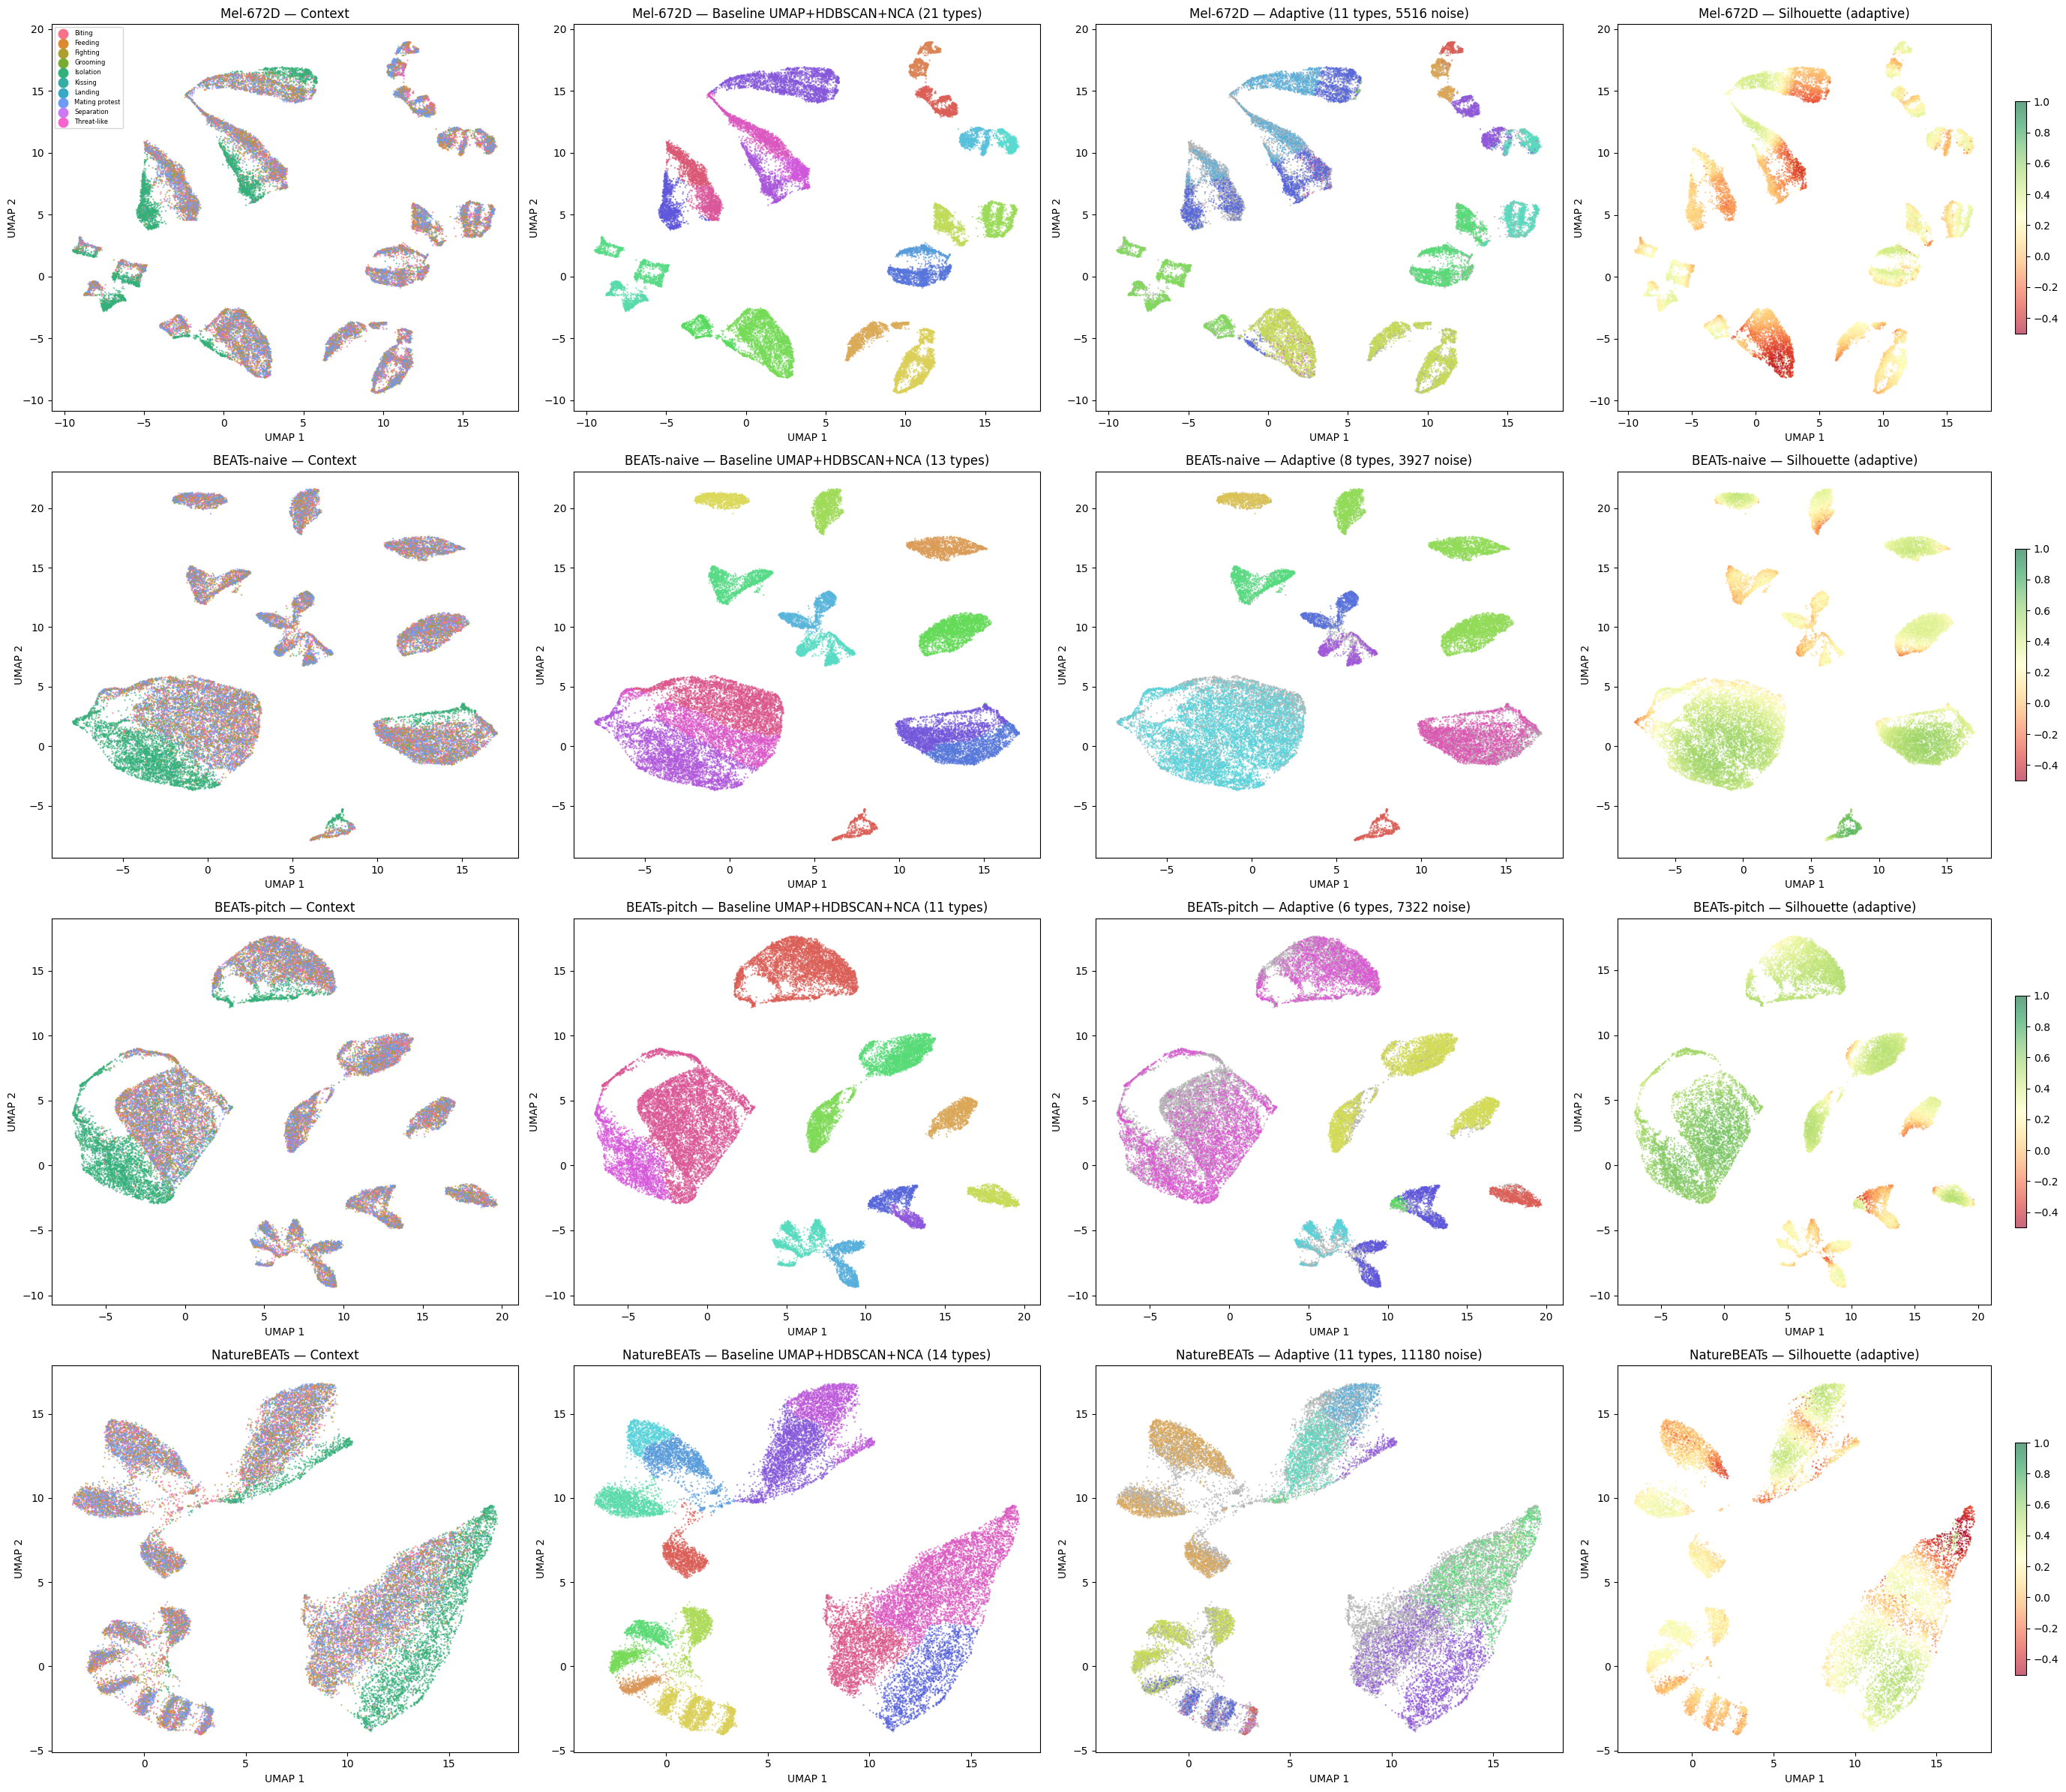

In [16]:
ctx_labels = seg_df['context_name'].values
unique_ctx = sorted(set(ctx_labels))
pal_ctx = sns.color_palette('husl', len(unique_ctx))
color_map_ctx = {c: pal_ctx[i] for i, c in enumerate(unique_ctx)}
colors_ctx = [color_map_ctx[c] for c in ctx_labels]

_row_defs = [
    (res_mel, umap_mel, 'Mel-672D'),
    (res_naive, umap_naive, 'BEATs-naive'),
    (res_pitch, umap_pitch, 'BEATs-pitch'),
    (res_nature, umap_nature, 'NatureBEATs'),
]
all_results, all_umaps, all_names = [], [], []
for r, u, n in _row_defs:
    if r is not None:
        all_results.append(r)
        all_umaps.append(u)
        all_names.append(n)

fig, axes = plt.subplots(len(all_results), 4, figsize=(28, 6 * len(all_results)))
if len(all_results) == 1:
    axes = axes[np.newaxis, :]

for row, (res, umap_2d, name) in enumerate(zip(all_results, all_umaps, all_names)):
    # Context
    axes[row, 0].scatter(umap_2d[:, 0], umap_2d[:, 1], c=colors_ctx, s=0.5, alpha=0.6)
    axes[row, 0].set_title(f'{name} — Context')
    if row == 0:
        for c in unique_ctx:
            axes[row, 0].scatter([], [], c=[color_map_ctx[c]], label=c, s=20)
        axes[row, 0].legend(fontsize=6, markerscale=2, loc='best')

    # Baseline: UMAP + HDBSCAN + NCA (same coloring as adaptive_tokenization)
    hdb = hdb_labels_by_name[name]
    n_cl_base = int(np.max(hdb)) + 1 if len(hdb) else 0
    pal_base = sns.color_palette('hls', max(n_cl_base, 1))
    colors_base = [pal_base[int(l)] if l >= 0 else (0.7, 0.7, 0.7) for l in hdb]
    axes[row, 1].scatter(umap_2d[:, 0], umap_2d[:, 1], c=colors_base, s=0.5, alpha=0.6)
    axes[row, 1].set_title(f'{name} — Baseline UMAP+HDBSCAN+NCA ({n_cl_base} types)')

    # Adaptive labels
    labels = res['labels']
    unique_ids = sorted(set(labels[labels >= 0]))
    pal_at = sns.color_palette('hls', max(len(unique_ids), 1))
    id_to_color = {uid: pal_at[i] for i, uid in enumerate(unique_ids)}
    colors_at = [(.7, .7, .7) if l == -1 else id_to_color.get(l, (.5,.5,.5)) for l in labels]
    n_noise = (labels == -1).sum()
    axes[row, 2].scatter(umap_2d[:, 0], umap_2d[:, 1], c=colors_at, s=0.5, alpha=0.6)
    axes[row, 2].set_title(f'{name} — Adaptive ({len(unique_ids)} types, {n_noise} noise)')

    # Silhouette heatmap (per-sample, adaptive labels)
    non_noise = labels >= 0
    if non_noise.sum() > 10 and len(unique_ids) >= 2:
        from sklearn.metrics import silhouette_samples
        sil_vals = np.full(len(labels), np.nan)
        sil_vals[non_noise] = silhouette_samples(res['X'][non_noise], labels[non_noise])
        sc = axes[row, 3].scatter(umap_2d[:, 0], umap_2d[:, 1], c=sil_vals,
                                  cmap='RdYlGn', s=0.5, alpha=0.6, vmin=-0.5, vmax=1)
        plt.colorbar(sc, ax=axes[row, 3], shrink=0.6)
        axes[row, 3].set_title(f'{name} — Silhouette (adaptive)')
    else:
        axes[row, 3].set_title(f'{name} — silhouette N/A')

for ax in axes.flat:
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

## 5. Metrics Comparison Table

In [17]:
ctx_enc = LabelEncoder().fit_transform(seg_df["context_name"].values)

rows = []

# Baseline: silhouette/noise on raw HDBSCAN; RQ1 ARI/NMI vs acoustic proxy (per-emitter mean); context ARI/NMI = diagnostic
for name, X in [
    ("Mel-672D", X_mel),
    ("BEATs-naive", X_beats_naive),
    ("BEATs-pitch", X_beats_pitch),
    ("NatureBEATs", X_nature_beats),
]:
    raw = hdb_labels_raw_by_name[name]
    lb = hdb_labels_by_name[name]
    emb2d = umap_2d_by_name[name]
    cq = ev.cluster_quality(emb2d, raw)
    ca = ev.context_alignment(ctx_enc, lb)
    rp = ev.repertoire_agreement_acoustic_proxy(
        lb, ACOUSTIC_PROXY_LABELS, seg_df, proxy_mask=ACOUSTIC_PROXY_MASK
    )
    vd = ev.vocabulary_diagnostics(lb, seg_df)
    seq_h = _seq_df_from_labels(seg_df, lb)
    seqs = [list(s) for s in seq_h["seq"]]
    comp = ev.sequence_compressibility(seqs) if seqs else float("nan")

    rows.append({
        "Embedding": name,
        "Tokenizer": "Baseline",
        "Vocab size": vd["vocab_size"],
        "Noise %": f"{cq['noise_frac']:.1%}",
        "Silhouette": f"{cq['silhouette']:.3f}",
        "ARI_proxy": f"{rp['ari_mean']:.3f}",
        "NMI_proxy": f"{rp['nmi_mean']:.3f}",
        "ARI_ctx": f"{ca['ari']:.3f}",
        "NMI_ctx": f"{ca['nmi']:.3f}",
        "Emitter reuse": f"{vd['mean_cross_emitter_reuse']:.2f}",
        "Compress": f"{comp:.2f}",
    })

# Adaptive (+ BPE on sequences)
for res in all_results:
    labels = res["labels"]
    cq = ev.cluster_quality(res["X"], labels)
    ca = ev.context_alignment(ctx_enc, labels)
    rp = ev.repertoire_agreement_acoustic_proxy(
        labels, ACOUSTIC_PROXY_LABELS, seg_df, proxy_mask=ACOUSTIC_PROXY_MASK
    )
    vd = ev.vocabulary_diagnostics(labels, res["seg_df"])
    seqs = [list(s) for s in res["seq_df"]["seq"]]
    comp = ev.sequence_compressibility(seqs)

    rows.append({
        "Embedding": res["name"],
        "Tokenizer": "Adaptive+BPE",
        "Vocab size": vd["vocab_size"],
        "Noise %": f"{cq['noise_frac']:.1%}",
        "Silhouette": f"{cq['silhouette']:.3f}",
        "ARI_proxy": f"{rp['ari_mean']:.3f}",
        "NMI_proxy": f"{rp['nmi_mean']:.3f}",
        "ARI_ctx": f"{ca['ari']:.3f}",
        "NMI_ctx": f"{ca['nmi']:.3f}",
        "Emitter reuse": f"{vd['mean_cross_emitter_reuse']:.2f}",
        "Compress": f"{comp:.2f}",
    })

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

  Embedding    Tokenizer  Vocab size Noise % Silhouette   ARI   NMI Emitter reuse Compress
   Mel-672D     Baseline          21    8.3%      0.535 0.043 0.106          0.91     3.67
BEATs-naive     Baseline          13   34.7%      0.628 0.119 0.121          0.94     3.13
BEATs-pitch     Baseline          11   14.8%      0.583 0.053 0.106          0.94     2.73
NatureBEATs     Baseline          14   34.2%      0.536 0.052 0.095          0.94     3.19
   Mel-672D Adaptive+BPE          12   20.4%      0.106 0.045 0.073          0.92     3.59
BEATs-naive Adaptive+BPE           9   14.5%      0.363 0.049 0.058          0.94     3.61
BEATs-pitch Adaptive+BPE           7   27.0%      0.409 0.030 0.049          0.93     3.49
NatureBEATs Adaptive+BPE          12   41.3%      0.172 0.024 0.071          0.83     3.54


## 6. HP1: Context Classification

In [18]:
clf_rows = []

for name in ["Mel-672D", "BEATs-naive", "BEATs-pitch", "NatureBEATs"]:
    seq_h = _seq_df_from_labels(seg_df, hdb_labels_by_name[name])
    try:
        feat = build_feature_matrix(seq_h)
        cr = classify_context(seq_h, feat, random_state=RANDOM_STATE)
        clf_rows.append({
            "Embedding": name,
            "Tokenizer": "Baseline",
            "F1(orig)": f"{cr['f1_orig']:.3f}",
            "Acc(orig)": f"{cr['acc_orig']:.3f}",
            "F1(perm)": f"{cr['f1_perm']:.3f}",
            "Delta": f"{cr['f1_orig'] - cr['f1_perm']:+.3f}",
        })
    except Exception as e:
        print(f"{name} (Baseline): classification failed — {e}")

for res in all_results:
    feat = build_feature_matrix(res["seq_df"])
    try:
        cr = classify_context(res["seq_df"], feat, random_state=RANDOM_STATE)
        clf_rows.append({
            "Embedding": res["name"],
            "Tokenizer": "Adaptive+BPE",
            "F1(orig)": f"{cr['f1_orig']:.3f}",
            "Acc(orig)": f"{cr['acc_orig']:.3f}",
            "F1(perm)": f"{cr['f1_perm']:.3f}",
            "Delta": f"{cr['f1_orig'] - cr['f1_perm']:+.3f}",
        })
    except Exception as e:
        print(f'{res["name"]} (Adaptive): classification failed — {e}')

clf_df = pd.DataFrame(clf_rows)
print(clf_df.to_string(index=False))

  Embedding    Tokenizer F1(orig) Acc(orig) F1(perm)  Delta
   Mel-672D     Baseline    0.276     0.351    0.270 +0.006
BEATs-naive     Baseline    0.301     0.382    0.298 +0.003
BEATs-pitch     Baseline    0.276     0.362    0.275 +0.001
NatureBEATs     Baseline    0.279     0.361    0.274 +0.005
   Mel-672D Adaptive+BPE    0.200     0.289    0.198 +0.003
BEATs-naive Adaptive+BPE    0.216     0.297    0.211 +0.004
BEATs-pitch Adaptive+BPE    0.207     0.291    0.201 +0.007
NatureBEATs Adaptive+BPE    0.217     0.311    0.218 -0.001


## 7. Maximal Repeats & Network Metrics

In [19]:
mr_rows = []

for name in ["Mel-672D", "BEATs-naive", "BEATs-pitch", "NatureBEATs"]:
    seq_h = _seq_df_from_labels(seg_df, hdb_labels_by_name[name])
    seqs = [list(s) for s in seq_h["seq"]]
    mr = ev.maximal_repeats_stats(seqs)
    net = ev.network_metrics(seqs)
    mr_rows.append({
        "Embedding": name,
        "Tokenizer": "Baseline",
        "Mean MR": f"{mr['mean_mr_len']:.2f}",
        "Max MR": mr["max_mr_len"],
        "Nodes": net["nodes"],
        "Edges": net["edges"],
        "Density": f"{net['density']:.3f}",
        "Avg C": f"{net['avg_clustering']:.3f}",
    })

for res in all_results:
    seqs = [list(s) for s in res["seq_df"]["seq"]]
    mr = ev.maximal_repeats_stats(seqs)
    net = ev.network_metrics(seqs)
    mr_rows.append({
        "Embedding": res["name"],
        "Tokenizer": "Adaptive+BPE",
        "Mean MR": f"{mr['mean_mr_len']:.2f}",
        "Max MR": mr["max_mr_len"],
        "Nodes": net["nodes"],
        "Edges": net["edges"],
        "Density": f"{net['density']:.3f}",
        "Avg C": f"{net['avg_clustering']:.3f}",
    })

mr_df = pd.DataFrame(mr_rows)
print(mr_df.to_string(index=False))

  Embedding    Tokenizer Mean MR  Max MR  Nodes  Edges Density Avg C
   Mel-672D     Baseline    1.52       6     21    433   1.031 0.991
BEATs-naive     Baseline    1.84      13     13    169   1.083 1.000
BEATs-pitch     Baseline    1.96      11     11    118   1.073 0.982
NatureBEATs     Baseline    1.75       8     14    194   1.066 0.989
   Mel-672D Adaptive+BPE    1.20       4     32    748   0.754 0.900
BEATs-naive Adaptive+BPE    1.20       4     29    564   0.695 0.879
BEATs-pitch Adaptive+BPE    1.17       4     27    495   0.705 0.892
NatureBEATs Adaptive+BPE    1.20       4     32    688   0.694 0.876


## 8. Summary

In [20]:
print('=' * 70)
print('FULL COMPARISON: Baseline (UMAP+HDBSCAN+NCA) vs Adaptive (+BPE)')
print('=' * 70)
print()
print('Cluster & Vocabulary Metrics:')
print(comp_df.to_string(index=False))
print()
print('Context Classification (HP1):')
print(clf_df.to_string(index=False))
print()
print('Maximal Repeats & Network:')
print(mr_df.to_string(index=False))

FULL COMPARISON: Baseline (UMAP+HDBSCAN+NCA) vs Adaptive (+BPE)

Cluster & Vocabulary Metrics:
  Embedding    Tokenizer  Vocab size Noise % Silhouette   ARI   NMI Emitter reuse Compress
   Mel-672D     Baseline          21    8.3%      0.535 0.043 0.106          0.91     3.67
BEATs-naive     Baseline          13   34.7%      0.628 0.119 0.121          0.94     3.13
BEATs-pitch     Baseline          11   14.8%      0.583 0.053 0.106          0.94     2.73
NatureBEATs     Baseline          14   34.2%      0.536 0.052 0.095          0.94     3.19
   Mel-672D Adaptive+BPE          12   20.4%      0.106 0.045 0.073          0.92     3.59
BEATs-naive Adaptive+BPE           9   14.5%      0.363 0.049 0.058          0.94     3.61
BEATs-pitch Adaptive+BPE           7   27.0%      0.409 0.030 0.049          0.93     3.49
NatureBEATs Adaptive+BPE          12   41.3%      0.172 0.024 0.071          0.83     3.54

Context Classification (HP1):
  Embedding    Tokenizer F1(orig) Acc(orig) F1(perm)  D